<a href="https://colab.research.google.com/github/Kingcoder44/skin-disease-classification-prototype/blob/main/skin_disease_classification_prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle
from google.colab import files
files.upload()   # upload kaggle.json (your Kaggle API key)
!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d pacificrm/skindiseasedataset
!unzip -q skindiseasedataset.zip -d skindiseasedataset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/pacificrm/skindiseasedataset
License(s): CC0-1.0
 98% 1.34G/1.36G [00:15<00:00, 176MB/s]
100% 1.36G/1.36G [00:15<00:00, 94.7MB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 🧠 Dermatology Meets Deep Learning: Classifying 22 Skin Diseases with ResNet & EfficientNet
Skin diseases are some of the most common conditions affecting people globally. Yet, early and accurate diagnosis remains a challenge, especially in underserved areas. In this notebook, we explore how deep learning can be leveraged to automatically classify 22 different skin diseases from dermatoscopic images using PyTorch.

# 🚀 What You'll Find in This Notebook:
✅ Comprehensive pipeline using torchvision and efficientnet_pytorch

📊 Enhanced EDA with visual inspection and class imbalance handling

🧠 Two powerful CNN models:

> ResNet18 as our baseline

> EfficientNet-B0 for high performance

⚖️ Weighted loss to combat class imbalance

🎯 Performance metrics including accuracy, F1-score, ROC, and PR curves

🔥 Grad-CAM visualizations to understand what the model is learning


# 📌 Why This Notebook Stands Out:
Clinical relevance: Insight into model performance for real-world dermatology applications

Explainability: Understandable predictions via Grad-CAM

Full reproducibility: All code blocks included, from loading to evaluation

# Imports & Device Setup

In [ ]:
import os
import torch
import numpy as np
from torchvision import datasets, transforms, models
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📦 Using device: {device}")

📦 Using device: cuda


# Paths & Basic Config

In [ ]:
train_dir = "/content/skindiseasedataset/train"
test_dir = "/content/skindiseasedataset/test"


IMAGE_SIZE = 224
BATCH_SIZE = 32

# Data Transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [ ]:
import os

for root, dirs, files in os.walk("/content/skindiseasedataset", topdown=True):
    print(root, dirs, files[:5])  # show up to 5 files


/content/skindiseasedataset ['SkinDisease'] ['Readme.md']
/content/skindiseasedataset/SkinDisease ['SkinDisease'] []
/content/skindiseasedataset/SkinDisease/SkinDisease ['train', 'test'] []
/content/skindiseasedataset/SkinDisease/SkinDisease/train ['DrugEruption', 'Actinic_Keratosis', 'Psoriasis', 'Vascular_Tumors', 'Moles', 'Candidiasis', 'Lichen', 'Lupus', 'Rosacea', 'Seborrh_Keratoses', 'Infestations_Bites', 'Tinea', 'SkinCancer', 'Acne', 'Warts', 'Vasculitis', 'Vitiligo', 'Bullous', 'Eczema', 'Sun_Sunlight_Damage', 'Unknown_Normal', 'Benign_tumors'] []
/content/skindiseasedataset/SkinDisease/SkinDisease/train/DrugEruption [] ['skin_lesion_urticaria_high.jpeg', 'drug-eruptions-77.jpeg', 'images307.jpeg', 'drug_eruption_1_dilantin_hig.jpeg', 'images398.jpeg']
/content/skindiseasedataset/SkinDisease/SkinDisease/train/Actinic_Keratosis [] ['3743__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg', 'actinic-cheilitis-sq-cell-lip-8.jpeg', 'images259.jpeg', '3746__ProtectWyJQcm90Z

# Datasets & Loaders

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Paths (adjusted for Colab)
train_dir = "/content/skindiseasedataset/SkinDisease/SkinDisease/train"
test_dir  = "/content/skindiseasedataset/SkinDisease/SkinDisease/test"

# ImageNet normalization values
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

# Data loaders (num_workers=0 for Colab)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Class names
class_names = train_dataset.classes
print(f"✅ Loaded {len(train_dataset)} training and {len(test_dataset)} test images")
print(f"📚 Number of classes: {len(class_names)} → {class_names}")


✅ Loaded 13898 training and 1546 test images
📚 Number of classes: 22 → ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']


# Enhanced EDA

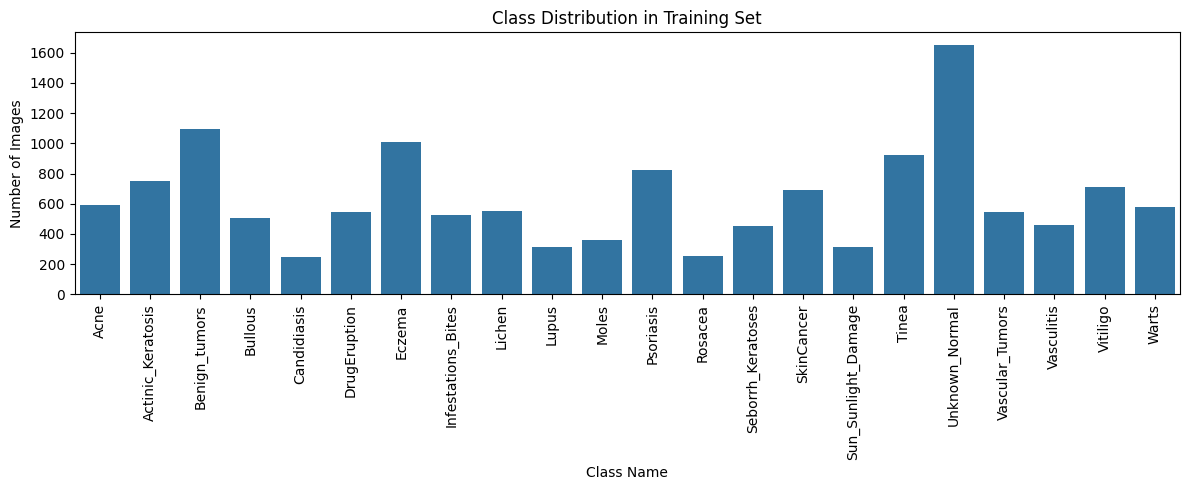

In [ ]:
import seaborn as sns
from collections import Counter

# 1. Class distribution bar chart
label_counts = Counter(train_dataset.targets)
plt.figure(figsize=(12, 5))
sns.barplot(x=[class_names[i] for i in label_counts.keys()], y=list(label_counts.values()))
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.xlabel("Class Name")
plt.tight_layout()
plt.show()

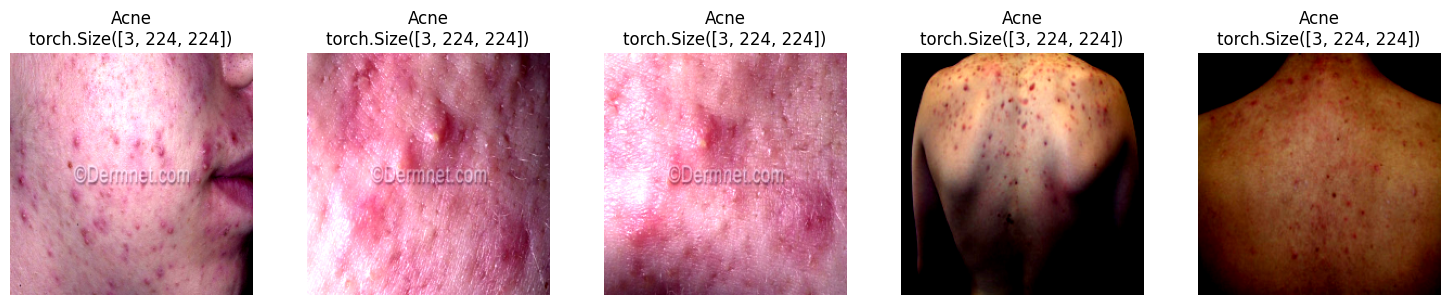

In [ ]:
# 2. Visual check of sample images (with titles and shape info)
def visualize_samples(dataset, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        image, label = dataset[i]
        img_display = image.permute(1, 2, 0).numpy() * 0.5 + 0.5
        axes[i].imshow(img_display)
        axes[i].set_title(f"{class_names[label]}\n{image.shape}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset)

In [ ]:
# 3. Check image shape consistency
shapes = [img[0].shape for img in train_dataset]
shape_counts = Counter(shapes)
print("🖼️ Image shapes in dataset:", shape_counts)

KeyboardInterrupt: 

# Compute Weighted Loss

In [ ]:
labels = train_dataset.targets
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels),
                                     y=np.array(labels))
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"📊 Class weights tensor: {class_weights}")

📊 Class weights tensor: tensor([1.0653, 0.8446, 0.5780, 1.2534, 2.5473, 1.1549, 0.6255, 1.2056, 1.1424,
        2.0313, 1.7499, 0.7704, 2.4871, 1.3884, 0.9116, 2.0248, 0.6844, 0.3826,
        1.1634, 1.3703, 0.8848, 1.0892], device='cuda:0')


# Resnet18 Model, Optimizer, Scheduler

In [ ]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.3)
print("✅ Model ready and optimizer configured.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


✅ Model ready and optimizer configured.


# Split train_dataset into Train and Validation

In [ ]:
from torch.utils.data import random_split, DataLoader

# Set split ratio
val_ratio = 0.1
train_size = int((1 - val_ratio) * len(train_dataset))
val_size = len(train_dataset) - train_size

# Split dataset
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)

# Full Training Code

Here is the full training loop with:

> Class-weighted loss

> Early stopping

> Model checkpointing

> Learning rate scheduler

> Tracking and plotting learning curves

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import os

# Loss function with computed class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=2,  min_lr=1e-6)

# Training configs
EPOCHS = 20
best_val_acc = 0
patience = 4
early_stop_counter = 0
save_path = "best_skin_model.pth"

# For logging
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= total
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}  Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Early Stopping & Checkpointing
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), save_path)
        print("📌 Best model saved.")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("⏹️ Early stopping triggered.")
            break

# Load best model
model.load_state_dict(torch.load(save_path))
print("✅ Training complete. Best model loaded.")

Epoch 1/20  Train Loss: 2.5413, Acc: 0.2472  Val Loss: 2.7493, Acc: 0.2381
📌 Best model saved.
Epoch 2/20  Train Loss: 2.1517, Acc: 0.3464  Val Loss: 2.0107, Acc: 0.3820
📌 Best model saved.
Epoch 3/20  Train Loss: 1.8945, Acc: 0.4139  Val Loss: 1.8931, Acc: 0.4144
📌 Best model saved.
Epoch 4/20  Train Loss: 1.6756, Acc: 0.4696  Val Loss: 1.9375, Acc: 0.4403
📌 Best model saved.
Epoch 5/20  Train Loss: 1.4935, Acc: 0.5238  Val Loss: 1.8558, Acc: 0.4547
📌 Best model saved.
Epoch 6/20  Train Loss: 1.2325, Acc: 0.5951  Val Loss: 1.7533, Acc: 0.5086
📌 Best model saved.
Epoch 7/20  Train Loss: 0.9794, Acc: 0.6677  Val Loss: 1.7905, Acc: 0.5230
📌 Best model saved.
Epoch 8/20  Train Loss: 0.7106, Acc: 0.7472  Val Loss: 2.2488, Acc: 0.4763
Epoch 9/20  Train Loss: 0.5285, Acc: 0.8158  Val Loss: 2.4182, Acc: 0.4986
Epoch 10/20  Train Loss: 0.3837, Acc: 0.8649  Val Loss: 2.4423, Acc: 0.5007
Epoch 11/20  Train Loss: 0.1211, Acc: 0.9619  Val Loss: 2.1868, Acc: 0.5993
📌 Best model saved.
Epoch 12/20  

# Evaluate on Test Set

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Put model in evaluation mode
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

               Acne       0.64      0.72      0.68        65
  Actinic_Keratosis       0.52      0.63      0.57        83
      Benign_tumors       0.36      0.58      0.44       121
            Bullous       0.69      0.49      0.57        55
        Candidiasis       0.50      0.56      0.53        27
       DrugEruption       0.57      0.57      0.57        61
             Eczema       0.55      0.53      0.54       112
 Infestations_Bites       0.45      0.35      0.39        60
             Lichen       0.51      0.38      0.43        61
              Lupus       0.36      0.29      0.32        34
              Moles       0.59      0.40      0.48        40
          Psoriasis       0.46      0.56      0.51        88
            Rosacea       0.75      0.64      0.69        28
  Seborrh_Keratoses       0.69      0.53      0.60        51
         SkinCancer       0.44      0.45      0.45        77
Sun_Sunlight_Damage    

# Confusion Matrix

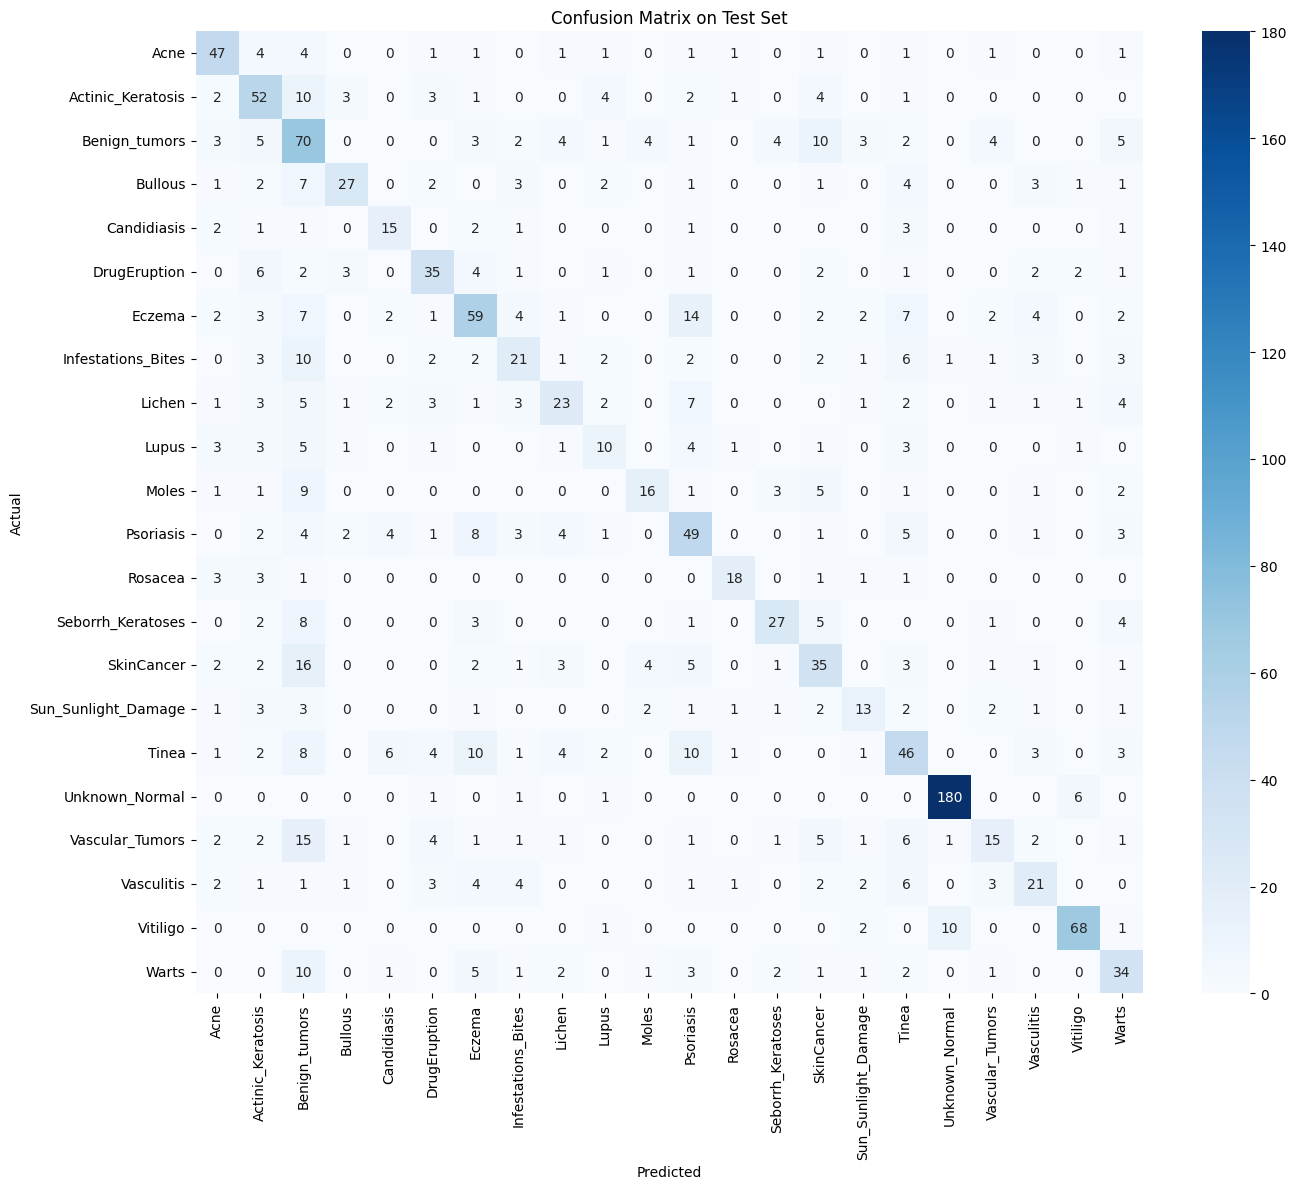

In [ ]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
labels = test_dataset.classes  # This should match your class names

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🩺 Dermatological Disease Classification with ResNet18 (PyTorch)

This notebook presents a deep learning pipeline to classify 22 different skin conditions using images. We trained a ResNet18 model and evaluated its performance with standard metrics, confusion matrix, and sample visualizations.

---

## 🔧 Setup & Configuration

- **Environment:** Google Colab with GPU support  
- **Data Preparation:** Defined paths, data loaders, and image transforms  
  - Resize → 224×224  
  - Normalize  
  - Flip/rotate for augmentation  
- **Hyperparameters:**  
  - `BATCH_SIZE = 32`  
  - `IMAGE_SIZE = 224`  

---

## 📊 Exploratory Data Analysis (EDA)

- Visualized class distribution (imbalance observed)  
- Displayed sample training images with labels  
- Checked image shape consistency  

---

## ⚖️ Class Imbalance Handling

- Computed class weights using `sklearn.utils.class_weight`  
- Integrated into `nn.CrossEntropyLoss` for balanced training  

---

## 🧠 Model: ResNet18

- **Architecture:** Initialized pretrained ResNet18  
- Replaced final FC layer with `nn.Linear(..., 22)` for classification  

**Training Setup:**

- Optimizer: Adam  
- Early stopping enabled  
- LR scheduler for convergence  

**Training Logs:**

- Final train accuracy: ~96%  
- Final validation accuracy: ~65%  
- Saved best-performing model checkpoint  

---

## 📈 Evaluation

- Classification report (accuracy, precision, recall, F1-score)  
- Confusion matrix heatmap of all 22 classes  
- Visual inspection of some misclassified samples  

---

## 🏁 Final Remarks

- ResNet18 successfully classifies 22 dermatological conditions with moderate accuracy.  
- **Challenges Identified:** Class imbalance and similarity across certain diseases  
- **Future Work:**  
  - Improve with EfficientNet  
  - Grad-CAM interpretability  
  - Deployment as a Streamlit/TFLite mobile app
